# Small Scale Robustness Check

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from skimage import io
from skimage import color
from skimage import exposure
from skimage.filters import gabor
from skimage.feature import structure_tensor

print("Imports loaded.")
DATA_DIR = Path("../data/amd_best")

image_paths = sorted(DATA_DIR.glob("*.tif"))

print(f"Found {len(image_paths)} images:")
for path in image_paths:
    print(" -", path.name)

Imports loaded.
Found 3 images:
 - amd_sample1.tif
 - amd_sample2.tif
 - amd_sample3.tif


In [2]:
# Import a whole bunch of functions
def load_roi(path, y0=180, y1=350):
    img = io.imread(path)

    img_gray = color.rgb2gray(img)

    img_norm = exposure.rescale_intensity(
        img_gray,
        in_range="image",
        out_range=(0, 1)
    )

    roi = img_norm[y0:y1, :]

    return roi

def compute_gabor_score(
    roi,
    frequency=0.02,
    theta=np.pi / 2
):
    real, imag = gabor(
        roi,
        frequency=frequency,
        theta=theta
    )

    return np.mean(np.abs(real))

def compute_anisotropy_score(
    roi,
    sigma=2
):
    Axx, Axy, Ayy = structure_tensor(
        roi,
        sigma=sigma
    )

    trace = Axx + Ayy
    det = Axx * Ayy - Axy**2

    sqrt_term = np.sqrt(
        np.maximum(trace**2 - 4 * det, 0)
    )

    lambda1 = (trace + sqrt_term) / 2
    lambda2 = (trace - sqrt_term) / 2

    anisotropy = (
        (lambda1 - lambda2)
        /
        (lambda1 + lambda2 + 1e-10)
    )

    return np.mean(anisotropy)

roi = load_roi(image_paths[0])
roi_barcode = roi[60:170, :]

gabor_score = compute_gabor_score(roi)
anisotropy_score = compute_anisotropy_score(roi_barcode)

print("Gabor score:", gabor_score)
print("Anisotropy score:", anisotropy_score)

Gabor score: 0.01411497313527342
Anisotropy score: 0.43011171157061345


In [3]:
def compute_features(path):
    roi = load_roi(path)
    roi_barcode = roi[60:170, :]

    gabor_score = compute_gabor_score(roi)
    anisotropy_score = compute_anisotropy_score(roi_barcode)

    return {
        "image": path.name,
        "gabor_score": gabor_score,
        "anisotropy_score": anisotropy_score
    }

feature_results = []

for path in image_paths:
    feature_results.append(compute_features(path))

features_df = pd.DataFrame(feature_results)

features_df

,image,gabor_score,anisotropy_score
0,amd_sample1.tif,0.014115,0.430112
1,amd_sample2.tif,0.002120,0.341469
2,amd_sample3.tif,0.004837,0.381750


In [4]:
features_df["gabor_norm"] = (
    features_df["gabor_score"]
    /
    features_df["gabor_score"].max()
)

features_df["anisotropy_norm"] = (
    features_df["anisotropy_score"]
    /
    features_df["anisotropy_score"].max()
)

features_df["barcoding_index"] = (
    0.5 * features_df["gabor_norm"]
    +
    0.5 * features_df["anisotropy_norm"]
)

features_df.sort_values("barcoding_index", ascending=False)

,image,gabor_score,anisotropy_score,gabor_norm,anisotropy_norm,barcoding_index
0,amd_sample1.tif,0.014115,0.430112,1.000000,1.000000,1.000000
2,amd_sample3.tif,0.004837,0.381750,0.342658,0.887560,0.615109
1,amd_sample2.tif,0.002120,0.341469,0.150214,0.793908,0.472061


In [5]:
# ROI Perturbation test
roi_ranges = {
    "170:340": (170, 340),
    "180:350": (180, 350),
    "190:360": (190, 360),
    "200:370": (200, 370),
    "210:380": (210, 380),
}
roi_uncertainty_results = []

for path in image_paths:
    for roi_label, (y0, y1) in roi_ranges.items():
        roi = load_roi(path, y0=y0, y1=y1)
        roi_barcode = roi[60:170, :]

        gabor_score = compute_gabor_score(roi)
        anisotropy_score = compute_anisotropy_score(roi_barcode)

        roi_uncertainty_results.append({
            "image": path.name,
            "roi": roi_label,
            "gabor_score": gabor_score,
            "anisotropy_score": anisotropy_score,
        })

roi_uncertainty_df = pd.DataFrame(roi_uncertainty_results)

roi_uncertainty_df.head()

,image,roi,gabor_score,anisotropy_score
0,amd_sample1.tif,170:340,0.015362,0.442864
1,amd_sample1.tif,180:350,0.014115,0.430112
2,amd_sample1.tif,190:360,0.013520,0.416946
3,amd_sample1.tif,200:370,0.011512,0.410990
4,amd_sample1.tif,210:380,0.009872,0.400505


In [6]:
roi_summary = (
    roi_uncertainty_df
    .groupby("image")
    .agg(
        gabor_mean=("gabor_score", "mean"),
        gabor_sd=("gabor_score", "std"),
        anisotropy_mean=("anisotropy_score", "mean"),
        anisotropy_sd=("anisotropy_score", "std"),
    )
    .reset_index()
)

roi_summary

,image,gabor_mean,gabor_sd,anisotropy_mean,anisotropy_sd
0,amd_sample1.tif,0.012876,0.002181,0.420283,0.016547
1,amd_sample2.tif,0.001908,0.000375,0.339571,0.005901
2,amd_sample3.tif,0.003327,0.001645,0.371739,0.017348


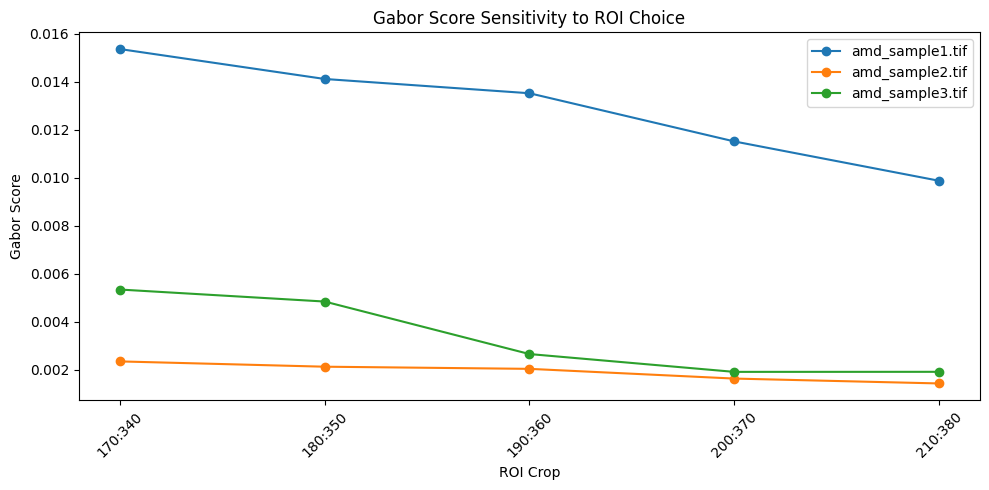

In [7]:
plt.figure(figsize=(10, 5))

for image_name in roi_uncertainty_df["image"].unique():
    df_img = roi_uncertainty_df[roi_uncertainty_df["image"] == image_name]

    plt.plot(
        df_img["roi"],
        df_img["gabor_score"],
        marker="o",
        label=image_name
    )

plt.xlabel("ROI Crop")
plt.ylabel("Gabor Score")
plt.title("Gabor Score Sensitivity to ROI Choice")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

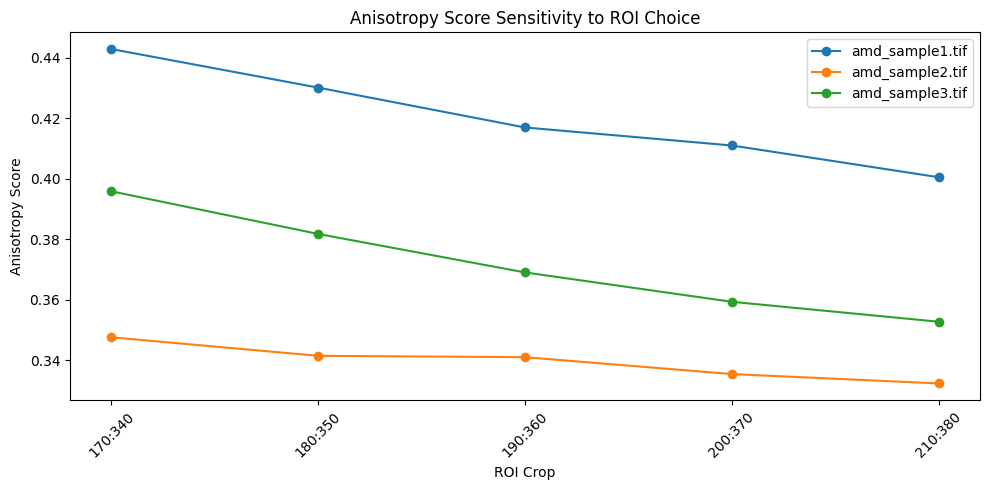

In [8]:
plt.figure(figsize=(10, 5))

for image_name in roi_uncertainty_df["image"].unique():
    df_img = roi_uncertainty_df[roi_uncertainty_df["image"] == image_name]

    plt.plot(
        df_img["roi"],
        df_img["anisotropy_score"],
        marker="o",
        label=image_name
    )

plt.xlabel("ROI Crop")
plt.ylabel("Anisotropy Score")
plt.title("Anisotropy Score Sensitivity to ROI Choice")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Conclusions

The ROI sensitivity analysis suggests that the proposed barcoding measurements are reasonably robust to moderate changes in ROI placement.

Although both Gabor and anisotropy scores varied in magnitude as the ROI was shifted, the relative ordering of the representative examples remained unchanged:

$$
\text{Sample 1}
>
\text{Sample 3}
>
\text{Sample 2}.
$$

This consistency was observed across both texture-based and anisotropy-based measurements, providing preliminary evidence that the methods are capturing a stable image characteristic rather than a crop-specific artifact.

Formal bootstrap-based uncertainty estimation was considered but deferred due to the computational expense of repeatedly evaluating Gabor and structure tensor features. For the current exploratory stage, ROI perturbation provided a practical and interpretable assessment of robustness.

Future work should focus on expanding the image dataset, developing automated ROI selection procedures, refining the composite barcoding index, and ultimately evaluating whether quantitative barcoding measurements are associated with AMD progression outcomes.